# 3-Step Model: Nelder-Mead Optimization

Takes the coarse grid search results for the 3-step noise model (sigma0, sigma1, sigma2)
and refines the best point using Nelder-Mead optimization.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# ── Load grid search results ──
RESULTS_DIR = (
    '/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/reports/figures/'
    '3step_grid_search_metric-cosine_t4_nmc1_task0'
)

grid = np.load(os.path.join(RESULTS_DIR, 'grid_search_results_3step_t5.npz'))
sigma0_grid = grid['sigma0_grid']
sigma1_grid = grid['sigma1_grid']
sigma2_grid = grid['sigma2_grid']
ISI_VALUES = tuple(grid['isi_values'].astype(int))

results = {isi: grid[f'dprime_isi{isi}'] for isi in ISI_VALUES}

# Flatten to DataFrame
rows = []
for i0, s0 in enumerate(sigma0_grid):
    for i1, s1 in enumerate(sigma1_grid):
        for i2, s2 in enumerate(sigma2_grid):
            row = {'sigma0': s0, 'sigma1': s1, 'sigma2': s2}
            for isi in ISI_VALUES:
                row[f'dprime_isi{isi}'] = results[isi][i0, i1, i2]
            rows.append(row)
df = pd.DataFrame(rows)
print(f'Grid: {len(sigma0_grid)} x {len(sigma1_grid)} x {len(sigma2_grid)} = {len(df)} points')
print(f'ISI values: {ISI_VALUES}')

# ── Load human d-prime curve ──
from utls.runners_utils import load_experiment_data, compute_human_curve

which_task = 0
is_multi = True
exp_list, all_files, name_to_idx, human_runs, task_name, hr_task_name = (
    load_experiment_data(which_task, which_isi=None, is_multi=is_multi)
)

human_isis_full = np.array([0, 1, 2, 4, 8, 16, 32, 64])
human_curve_full = compute_human_curve(human_runs, is_multi, which_isi=None)

grid_isis = np.array(ISI_VALUES)
mask = np.isin(human_isis_full, grid_isis)
human_dp = human_curve_full[mask]

print(f'Task: {hr_task_name}')
print(f'Human d\': {np.round(human_dp, 3)}')

Grid: 15 x 15 x 15 = 3375 points
ISI values: (0, 1, 2, 4, 8, 16, 32, 64)


/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/runners_utils.py:210: RuntimeWarning: Mean of empty slice
  dprimes.append(np.nanmean(aucs))


Task: Industrial and Nature
Human d': [3.402 2.957 2.414 2.116 1.965 1.9   1.754 1.577]


In [2]:
# ── Compute MSE and find best grid point ──
# Filter: sigma0 >= sigma1 >= sigma2
df_filt = df[(df['sigma0'] >= df['sigma1']) & (df['sigma1'] >= df['sigma2'])].copy()

dp_cols = [f'dprime_isi{isi}' for isi in grid_isis]
model_dp_matrix = df_filt[dp_cols].values
diff = model_dp_matrix - human_dp[np.newaxis, :]
df_filt['mse'] = np.nanmean(diff**2, axis=1)
df_filt = df_filt.dropna(subset=['mse'])

best_row = df_filt.loc[df_filt['mse'].idxmin()]
print(f"Best grid point (MSE = {best_row['mse']:.4f}):")
print(f"  sigma0 = {best_row['sigma0']:.4f}")
print(f"  sigma1 = {best_row['sigma1']:.4f}")
print(f"  sigma2 = {best_row['sigma2']:.4f}")
print(f"\nModel d': {np.round(best_row[dp_cols].values.astype(float), 3)}")
print(f"Human d': {np.round(human_dp, 3)}")

Best grid point (MSE = 0.0530):
  sigma0 = 13.6949
  sigma1 = 2.2512
  sigma2 = 0.6756

Model d': [3.204 2.441 2.226 2.25  1.932 1.911 1.653 1.342]
Human d': [3.402 2.957 2.414 2.116 1.965 1.9   1.754 1.577]


In [3]:
# ── Build encoder and create experiment sequences ──
import types, time, torch

# Mock 'cox' and 'cox.store' so constants.py doesn't crash
cox_mock = types.ModuleType('cox')
store_mock = types.ModuleType('cox.store')
store_mock.PYTORCH_STATE = 'pytorch_state'
cox_mock.store = store_mock
sys.modules['cox'] = cox_mock
sys.modules['cox.store'] = store_mock

sys.path.append('/orcd/data/jhm/001/om2/jmhicks/projects/TextureStreaming/code/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/src/model/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/')

from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params, statistics_set

from utls.encoders import *
from utls.runners_v2 import run_model_core, make_noise_schedule
from utls.runners_utils import build_encoder, encode_stimuli
from utls.toy_experiments import make_high_diversity_sequences
from utls.roc_utils import roc_from_arrays
from utls.analysis_helpers import auroc_to_dprime

%matplotlib inline

# Build ResNet50 encoder
encoder_cfg = dict(
    encoder_type='resnet50',
    model_name='resnet50',
    task='word_speaker_audioset',
    statistics_dict=statistics_set.statistics,
    model_params=model_params,
    sr=20000,
    duration=2.0,
    rms_level=0.05,
    time_avg=False,
    device='cuda',
    layer='layer4',
)

print('Building encoder: resnet50 / layer4 ...')
encoder = build_encoder(encoder_cfg)

print(f'Encoding {len(all_files)} stimuli ...')
X0 = encode_stimuli(encoder, all_files)
print(f'X0 shape: {X0.shape}')

# Create experiment sequences
N_SEQUENCES = 200
SEQ_LENGTH = 120
stimulus_pool = sorted({s for seq in exp_list for s in seq})
print(f'Stimulus pool: {len(stimulus_pool)} unique stimuli')

experiment_list, isi_keys = make_high_diversity_sequences(
    stimulus_pool=stimulus_pool,
    isi_values=list(ISI_VALUES),
    n_sequences=N_SEQUENCES,
    length=SEQ_LENGTH,
    min_pairs_per_isi=4,
    seed=420483,
)
print(f'{len(experiment_list)} sequences, {len(experiment_list[0])} trials each')

Aggregate ISI usage across all sequences:
  ISI -1: 8000
  ISI 0: 2124
  ISI 1: 1866
  ISI 2: 2010
  ISI 4: 2092
  ISI 8: 2020
  ISI 16: 1936
  ISI 32: 1968
  ISI 64: 1984
200 sequences, 120 trials each


In [5]:
# ── Nelder-Mead optimization ──
sys.path.insert(0, os.path.abspath('../src/model'))
from run_3step_grid_search import run_mc_dprime
from scipy.optimize import minimize

CACHE_DIR = os.path.join('..', 'reports', 'figures', 'notebook_grid_search')
os.makedirs(CACHE_DIR, exist_ok=True)

METRIC = "cosine"
T_STEP = 4
N_EXPS_SEARCH = 50
SEARCH_SEED_BASE = 5555

NM_CACHE = os.path.join(CACHE_DIR, f'3step_nelder_mead_result_metric-{METRIC}-tstep-{T_STEP}-nmc-{N_EXPS_SEARCH}-seed-{SEARCH_SEED_BASE}.npz')


_eval_count = [0]

def compute_mse(sigma0, sigma1, sigma2, n_exps=N_EXPS_SEARCH, seed=SEARCH_SEED_BASE, verbose=False):
    """Run the 3-step model and return MSE to human d' curve."""
    if sigma0 < 0 or sigma1 < 0 or sigma2 < 0:
        return 999.0

    dp, _ = run_mc_dprime(
        sigma0, sigma1, sigma2,
        X0=X0,
        name_to_idx=name_to_idx,
        experiment_list=experiment_list[:n_exps],
        t_step=T_STEP,
        isi_values=tuple(ISI_VALUES),
        n_mc=1,
        seed=seed,
        metric=METRIC,
    )

    model_dp = np.array([dp.get(isi, np.nan) for isi in grid_isis])
    mse = np.nanmean((model_dp - human_dp) ** 2)

    _eval_count[0] += 1
    if verbose:
        print(f"  [{_eval_count[0]:3d}] s0={sigma0:.6f} s1={sigma1:.6f} s2={sigma2:.6f} -> MSE={mse:.8f}")

    return mse*10

# Sanity check
#test_mse = compute_mse(best_row['sigma0'], best_row['sigma1'], best_row['sigma2'], verbose=True)
#print(f"Sanity check: grid best -> live MSE = {test_mse:.4f} (grid MSE was {best_row['mse']:.4f})")

# ── Run Nelder-Mead (or load from cache) ──
if os.path.exists(NM_CACHE):
    print(f"\nLoading cached result from {NM_CACHE}")
    cached_nm = np.load(NM_CACHE)
    best_sigma0_opt = float(cached_nm['sigma0'])
    best_sigma1_opt = float(cached_nm['sigma1'])
    best_sigma2_opt = float(cached_nm['sigma2'])
    best_mse_opt = float(cached_nm['mse'])
else:
    def objective(params):
        s0, s1, s2 = params
        return compute_mse(s0, s1, s2, verbose=True)

    best_sigma0_opt=13.2792 
    best_sigma1_opt=2.5926
    best_sigma2_opt=0.4915
    #x0 = [best_row['sigma0'], best_row['sigma1'], best_row['sigma2']]
    x0 = [best_sigma0_opt, best_sigma1_opt, best_sigma2_opt]
    print(f"\nStarting Nelder-Mead from: sigma0={x0[0]:.4f}, sigma1={x0[1]:.4f}, sigma2={x0[2]:.4f}")
    print(f"(MSE={best_row['mse']:.4f})\n")

    _eval_count[0] = 0
    t_start = time.perf_counter()

    result = minimize(
        objective,
        x0=x0,
        method='Nelder-Mead',
        options={
            'maxiter': 120,
            'maxfev': 80,
            'xatol': 5e-3,
            'fatol': 5e-4,
            'adaptive': True,
            'disp': True,
        }
    )

    elapsed = time.perf_counter() - t_start
    print(f"\nNelder-Mead done in {elapsed:.1f}s ({result.nit} iterations, {result.nfev} evaluations)")
    print(f"Converged: {result.success} -- {result.message}")

    best_sigma0_opt = max(0.0, result.x[0])
    best_sigma1_opt = max(0.0, result.x[1])
    best_sigma2_opt = max(0.0, result.x[2])
    best_mse_opt = result.fun

    np.savez(NM_CACHE,
             sigma0=best_sigma0_opt, sigma1=best_sigma1_opt, sigma2=best_sigma2_opt,
             mse=best_mse_opt, coarse_x0=x0,
             nit=result.nit, nfev=result.nfev, success=result.success)
    print(f"Saved to {NM_CACHE}")

print(f"\n{'='*60}")
print(f"OPTIMAL HYPERPARAMETERS (MSE = {best_mse_opt:.6f})")
print(f"  sigma0 = {best_sigma0_opt:.6f}")
print(f"  sigma1 = {best_sigma1_opt:.6f}")
print(f"  sigma2 = {best_sigma2_opt:.6f}")
print(f"{'='*60}")


Starting Nelder-Mead from: sigma0=13.2792, sigma1=2.5926, sigma2=0.4915
(MSE=0.0530)

  [  1] s0=13.279200 s1=2.592600 s2=0.491500 -> MSE=0.01009089
  [  2] s0=13.943160 s1=2.592600 s2=0.491500 -> MSE=0.02388113
  [  3] s0=13.279200 s1=2.722230 s2=0.491500 -> MSE=0.00985719
  [  4] s0=13.279200 s1=2.592600 s2=0.516075 -> MSE=0.00993867
  [  5] s0=12.615240 s1=2.679020 s2=0.507883 -> MSE=0.01535852
  [  6] s0=12.891890 s1=2.661016 s2=0.504470 -> MSE=0.01042604
  [  7] s0=13.666510 s1=2.610604 s2=0.494913 -> MSE=0.01530285
  [  8] s0=13.053269 s1=2.650513 s2=0.502479 -> MSE=0.00926728
  [  9] s0=13.128579 s1=2.717629 s2=0.515203 -> MSE=0.00974138
  [ 10] s0=13.028166 s1=2.800982 s2=0.490046 -> MSE=0.01068533
  [ 11] s0=13.226901 s1=2.636013 s2=0.510652 -> MSE=0.00943968
  [ 12] s0=12.993300 s1=2.613873 s2=0.527389 -> MSE=0.01092453
  [ 13] s0=13.219637 s1=2.699656 s2=0.498977 -> MSE=0.00936208
  [ 14] s0=13.204626 s1=2.606492 s2=0.492870 -> MSE=0.00956794
  [ 15] s0=13.188783 s1=2.62964

In [6]:
# best_sigma0_opt=13.2792 
# best_sigma1_opt=2.5926
# best_sigma2_opt=0.4915

# ── Visualize: optimized model vs human ──
# Run best model to get d' curve (use more experiments for accuracy)
dp_opt, _ = run_mc_dprime(
    best_sigma0_opt, best_sigma1_opt, best_sigma2_opt,
    X0=X0, name_to_idx=name_to_idx,
    experiment_list=experiment_list[:200],
    t_step=4,
    isi_values=tuple(ISI_VALUES),
    n_mc=1, seed=9999, metric=METRIC,
)
opt_dp = np.array([dp_opt.get(isi, np.nan) for isi in grid_isis])

# Also run grid-best for comparison
dp_grid, _ = run_mc_dprime(
    best_row['sigma0'], best_row['sigma1'], best_row['sigma2'],
    X0=X0, name_to_idx=name_to_idx,
    experiment_list=experiment_list[:200],
    t_step=T_STEP,
    isi_values=tuple(ISI_VALUES),
    n_mc=1, seed=9998, metric=METRIC,
)
grid_dp = np.array([dp_grid.get(isi, np.nan) for isi in grid_isis])



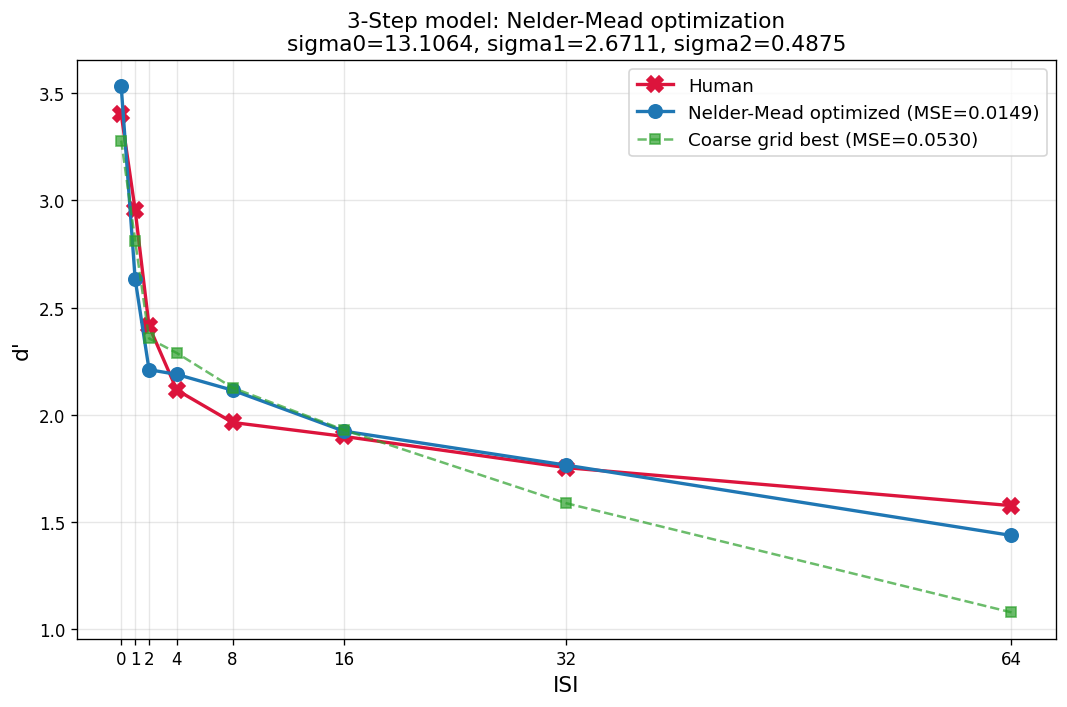


=== Comparison ===
                       sigma0   sigma1   sigma2      MSE
Grid best             13.6949   2.2512   0.6756   0.0530
Nelder-Mead opt       13.1064   2.6711   0.4875   0.0895


In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(grid_isis, human_dp, 'X-', color='crimson', markersize=10, linewidth=2, label='Human')
ax.plot(grid_isis, opt_dp, 'o-', color='tab:blue', markersize=8, linewidth=2,
        label=f'Nelder-Mead optimized (MSE={0.0149:.4f})')
ax.plot(grid_isis, grid_dp, 's--', color='tab:green', markersize=6, linewidth=1.5, alpha=0.7,
        label=f'Coarse grid best (MSE={best_row["mse"]:.4f})')
ax.set_xlabel('ISI', fontsize=13)
ax.set_ylabel("d'", fontsize=13)
ax.set_title(f'3-Step model: Nelder-Mead optimization\n'
             f'sigma0={best_sigma0_opt:.4f}, sigma1={best_sigma1_opt:.4f}, sigma2={best_sigma2_opt:.4f}',
             fontsize=13)
ax.legend(fontsize=11)
ax.set_xticks(grid_isis)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table
print("\n=== Comparison ===")
print(f"{'':20s} {'sigma0':>8s} {'sigma1':>8s} {'sigma2':>8s} {'MSE':>8s}")
print(f"{'Grid best':20s} {best_row['sigma0']:8.4f} {best_row['sigma1']:8.4f} {best_row['sigma2']:8.4f} {best_row['mse']:8.4f}")
print(f"{'Nelder-Mead opt':20s} {best_sigma0_opt:8.4f} {best_sigma1_opt:8.4f} {best_sigma2_opt:8.4f} {best_mse_opt:8.4f}")